# Getting Skagit Data

In [18]:
import geopandas as gpd
import os
import numpy as np
import csv

import xarray as xr
import matplotlib.pyplot as plt
from shapely.geometry import mapping
from rasterio.mask import mask

In [19]:
# create UA SWE dataset
path_ua = '../Dataset/UA_Data/'
files_ua = path_ua + '4km_SWE_Depth*.nc'
ds_ua = xr.open_mfdataset(files_ua, engine="netcdf4", data_vars='all')

In [20]:
# clip data
skagit_boundary = gpd.read_file('../Dataset/ShapeFiles/SkagitBoundary.json')

poly = skagit_boundary.geometry.to_list()
ua_skagit_clipped = ds_ua.SWE.rio.set_spatial_dims(x_dim='lon', y_dim='lat', inplace=True)
ua_skagit_clipped = ua_skagit_clipped.rio.write_crs("epsg:4326", inplace=True)
ua_skagit_clipped = ua_skagit_clipped.rio.clip(poly, crs="epsg:4326")

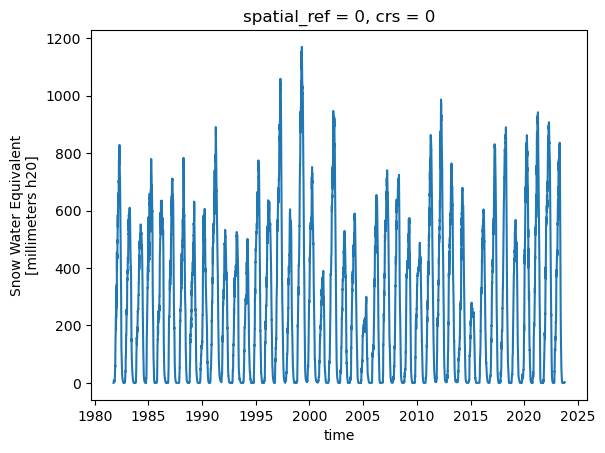

In [21]:
# plot mean
ua_skagit_clipped_mean = ua_skagit_clipped.mean(dim= ('lat', 'lon'))
ua_skagit_clipped_mean.plot()

In [4]:
skagit_boundary

,OBJECTID,AREA,PERIMETER,SKAGIT_,SKAGIT_ID,GRID_CODE,Shape_Leng,Shape_Area,geometry
0,1,8.060220e+09,948300.0,2,1,1,948300.0,8.060220e+09,"POLYGON ((-120.81726 49.26101, -120.8152 49.26..."


In [57]:
# read AR data
from pandas import to_datetime
import csv

AR_data = {}

with open('../Dataset/AR_Data/48N_event_data.csv') as f:
    reader = csv.reader(f)
    lines = list(reader)
    
    for line in lines:
        date = to_datetime(line[0], format='%Y%m%d%H')
        year = date.year
        scale = int(line[5])

        if year not in AR_data:
            AR_data[year] = {}

        AR_data[year][scale] = AR_data[year].get(scale, 0) + 1

In [59]:
print(list(AR_data.keys())[:5])

[1959, 1960, 1961, 1962, 1963]


In [60]:
year = 1959
print(AR_data.get(year))

{1: 3, 2: 5, 4: 1, 5: 1, 3: 1}


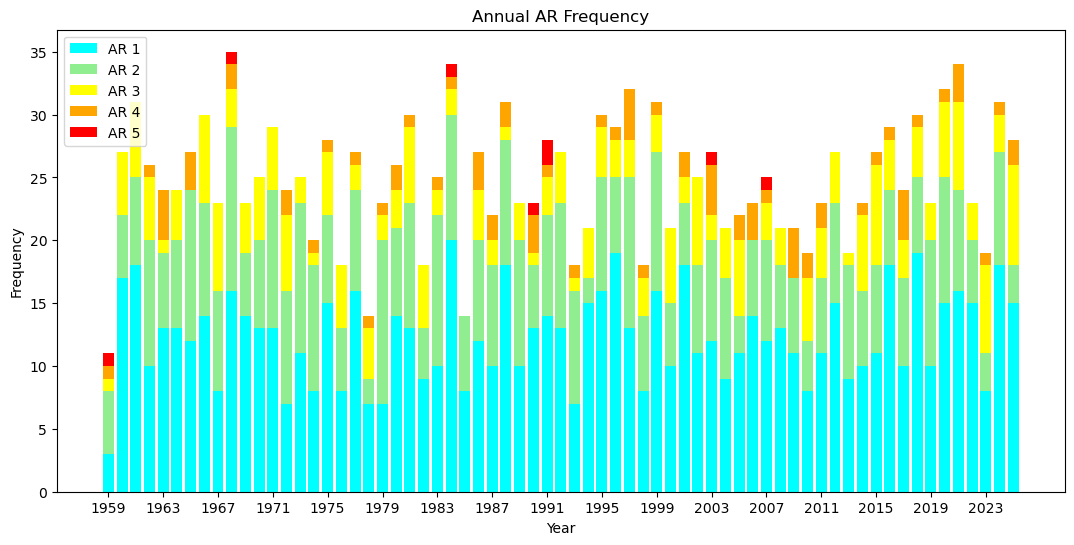

In [80]:
years = np.array(sorted(AR_data.keys()))
ar1 = []
ar2 = []
ar3 = []
ar4 = []
ar5 = []

for year in years:
    data = AR_data[year]
    
    ar1.append(data.get(1, 0))
    ar2.append(data.get(2, 0))
    ar3.append(data.get(3, 0))
    ar4.append(data.get(4, 0))
    ar5.append(data.get(5, 0))

ar1 = np.array(ar1)
ar2 = np.array(ar2)
ar3 = np.array(ar3)
ar4 = np.array(ar4)
ar5 = np.array(ar5)

plt.figure(figsize=(13, 6))

plt.bar(years, ar1, color='cyan')
plt.bar(years, ar2, bottom=ar1, color='lightgreen')
plt.bar(years, ar3, bottom=ar1+ar2, color='yellow')
plt.bar(years, ar4, bottom=ar1+ar2+ar3, color='orange')
plt.bar(years, ar5, bottom=ar1+ar2+ar3+ar4, color='r')

plt.xlabel("Year")
plt.ylabel("Frequency")
plt.legend(["AR 1", "AR 2", "AR 3", "AR 4", "AR 5"])
plt.title("Annual AR Frequency")
plt.xticks(np.arange(years.min(), years.max() + 1, 4))
plt.show()

In [10]:
skagit_boundary.explore()